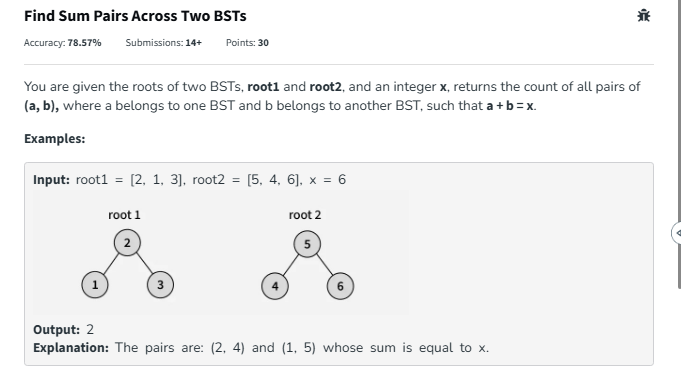
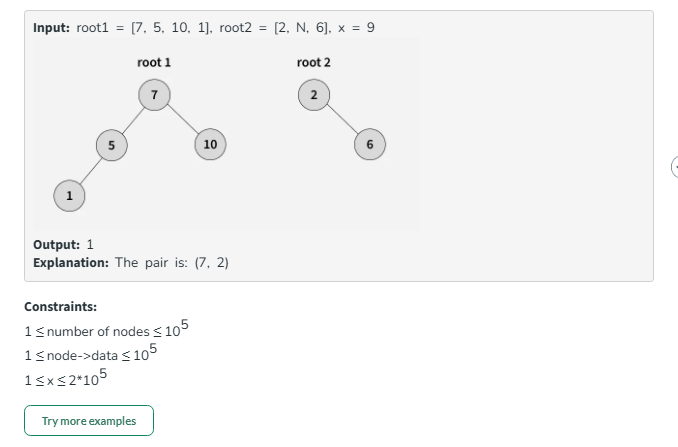

Algorithm: Count Pairs with Given Sum in Two BSTs

This algorithm uses an iterative two-pointer approach simulating inorder traversals to find pairs summing to x without extra space for storing all nodes.


1. Initialization

Create two stacks: s1 for inorder traversal of BST1 (ascending) and s2 for reverse inorder traversal of BST2 (descending).

Initialize pointers curr1 = root1 and curr2 = root2.

Initialize counter cnt = 0.

2. Iterative Traversal Loop

Continue while both stacks are non-empty:

A. Fill Stacks

BST1 (Leftmost): Push all left children of curr1 onto s1 until curr1 is null.

BST2 (Rightmost): Push all right children of curr2 onto s2 until curr2 is null.

B. Termination Check

If either s1 or s2 is empty, break the loop (no more pairs possible).

C. Compare and Move Pointers

| Condition | Action | Pointer Movement |
| :--- | :--- | :--- |
| **`sum == x`** | Increment `cnt`. Pop both stacks. | `curr1 = a.right` (next larger in BST1)<br>`curr2 = b.left` (next smaller in BST2) |
| **`sum < x`** | Sum too small; need larger value from BST1. Pop `s1`. | `curr1 = a.right` |
| **`sum > x`** | Sum too large; need smaller value from BST2. Pop `s2`. | `curr2 = b.left` |

3. return count

                8                         5
              /   \                      / \
             3     10                  2   18
            / \      \                / \
           1   6      14             1   3
              / \    /                    \
             5   7  13                     4   

| Step | Action: Fill Stacks | Stack `s1` (Top → Bottom) | Stack `s2` (Top → Bottom) | `a` (s1 top) | `b` (s2 top) | Sum (`a+b`) | Comparison | Action Taken | New `curr1` | New `curr2` | Count |
|:---:|:---|:---|:---|:---:|:---:|:---:|:---:|:---|:---|:---|:---:|
| **1** | Push left of 8; Push right of 5 | `[1, 3, 8]` | `[18, 5]` | **1** | **18** | **19** | `> 10` | Pop `s2` (18) | 1 | `18.left` (null) | 0 |
| **2** | No change (curr null) | `[1, 3, 8]` | `[5]` | **1** | **5** | **6** | `< 10` | Pop `s1` (1) | `1.right` (null) | 5 | 0 |
| **3** | No change (curr null) | `[3, 8]` | `[5]` | **3** | **5** | **8** | `< 10` | Pop `s1` (3) | `3.right` (6) | 5 | 0 |
| **4** | Push left of 6 | `[5, 6, 8]` | `[5]` | **5** | **5** | **10** | `== 10` | **Match!** Pop both | `5.right` (null) | `5.left` (2) | **1** |
| **5** | Push right chain of 2 | `[6, 8]` | `[4, 3, 2]` | **6** | **4** | **10** | `== 10` | **Match!** Pop both | `6.right` (7) | `4.left` (null) | **2** |
| **6** | Push left of 7 | `[7, 8]` | `[3, 2]` | **7** | **3** | **10** | `== 10` | **Match!** Pop both | `7.right` (null) | `3.left` (null) | **3** |
| **7** | No change (curr null) | `[8]` | `[2]` | **8** | **2** | **10** | `== 10` | **Match!** Pop both | `8.right` (10) | `2.left` (1) | **4** |
| **8** | Push left of 10; Push left of 1 | `[10]` | `[1]` | **10** | **1** | **11** | `> 10` | Pop `s2` (1) | 10 | `1.left` (null) | 4 |
| **9** | No change | `[10]` | `[]` | - | - | - | - | `s2` empty → **Break** | - | - | **4** |

In [ ]:
# find sum pairs across two bsts gfg practice
class Solution:
    def countPairs(self, root1, root2, x):
        s1 = []  # inorder stack for BST1
        s2 = []  # reverse inorder stack for BST2

        curr1 = root1
        curr2 = root2

        cnt = 0

        while True:

            # Push left chain of BST1
            while curr1:
                s1.append(curr1)
                curr1 = curr1.left

            # Push right chain of BST2
            while curr2:
                s2.append(curr2)
                curr2 = curr2.right

            # Termination
            if not s1 or not s2:
                break

            a = s1[-1]
            b = s2[-1]

            total = a.data + b.data

            if total == x:
                cnt += 1

                s1.pop()
                s2.pop()

                curr1 = a.right
                curr2 = b.left

            elif total < x:
                s1.pop()
                curr1 = a.right

            else:
                s2.pop()
                curr2 = b.left

        return cnt



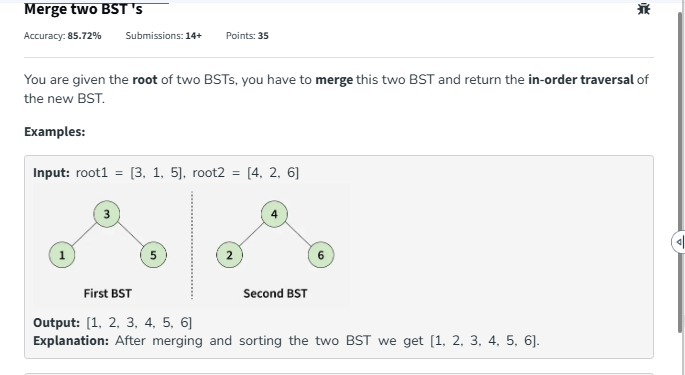
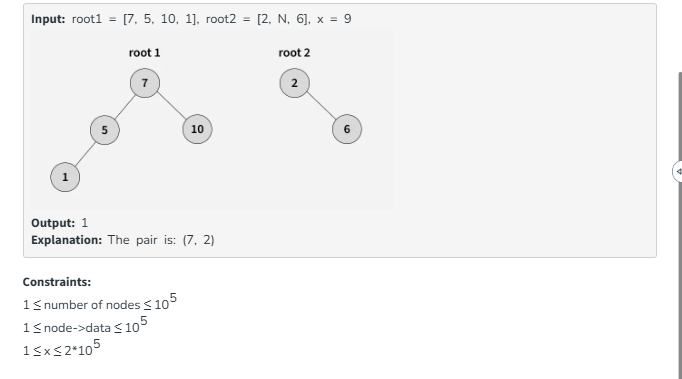

In [ ]:
'''
class Node:
    def __init__(self, val):
        self.data = val
        self.left = None
        self.right = None
'''

class Solution:
    def merge(self, root1, root2):
        # code here
        arr = []
        
        def inorder(root):
            
            if not root:
                return None
                
            inorder(root.left)
            arr.append(root.data)
            inorder(root.right)
            
        inorder(root1)
        inorder(root2)
        
        arr.sort()
        return arr

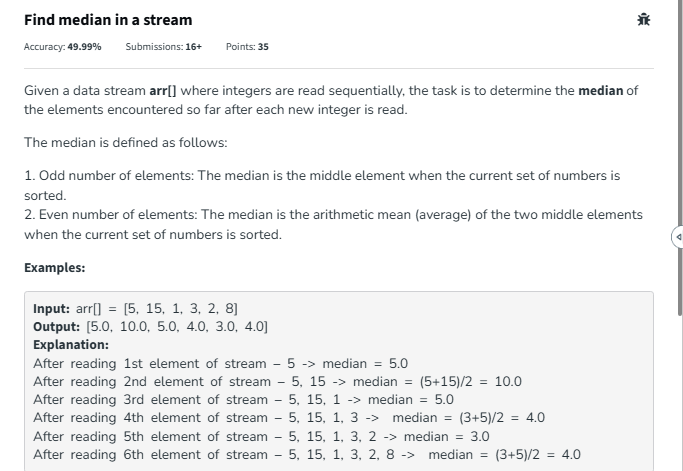
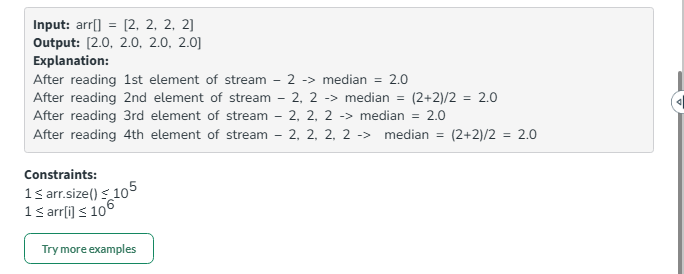

In [ ]:
import heapq
class Solution:
    def getMedian(self, arr):
        # code here
        n = len(arr)
        
        max_heap = []
        min_heap = []
        res = []
        
        for num in arr:
            
            heapq.heappush(max_heap, -num)
            
            heapq.heappush(min_heap, -heapq.heappop(max_heap))
            
            if len(min_heap) > len(max_heap):
                
                heapq.heappush(max_heap, -heapq.heappop(min_heap))
                
            if len(max_heap) > len(min_heap):
                
                res.append(-max_heap[0])
                
            else:
                
                res.append((-max_heap[0] + min_heap[0]) / 2)
                
        return res